最初に以下のセルを実行

In [62]:
%%capture
!pip install japanize-matplotlib
import japanize_matplotlib
from IPython.display import Markdown, display
import os
# キャッシュディレクトリを指定
os.environ['TORCH_HOME'] = str(CACHE_DIR)

In [49]:
NOTEBOOK_TITLE = "01_01 まずは使ってみよう"

from pathlib import Path
OUTPUT_DIR = Path('figures') / NOTEBOOK_TITLE
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = Path('cache')
CACHE_DIR.mkdir(exist_ok=True, parents=True)
display(Markdown(f"# {NOTEBOOK_TITLE}"))

# 01_01 まずは使ってみよう

### 日本語テキストの感情分析（文書分類の一種）

In [ ]:
%%capture
!pip install transformers[ja,sentencepiece,torch]

In [50]:
import pandas as pd
from transformers import pipeline
from huggingface_hub import hf_hub_url, get_hf_file_metadata

display(Markdown("### モデルをロード"))
repo_id = "llm-book/bert-base-japanese-v3-marc_ja"
classifier = pipeline(model=repo_id)

display(Markdown("##### モデルのパラメーターのファイルサイズを確認"))
file_size_mb = get_hf_file_metadata(
    hf_hub_url(repo_id=repo_id, filename="pytorch_model.bin")
).size / (1024 * 1024)
print(f"{file_size_mb:.2f} MB")

display(Markdown("### 入力となるテキスト"))
texts = [
    "この製品は素晴らしいです！",  # ポジティブ
    "全然気に入りませんでした。",  # ネガティブ
    "普通かなと思いました。",  # ニュートラル
    "とても楽しい経験でした。",  # ポジティブ
    "サービスが遅くて残念です。",  # ネガティブ
    "まあまあでしたが、期待していたほどではなかった。",  # ニュートラル/ネガティブ
    "この店のラーメンは最高だけど、接客が微妙だった。",  # ポジティブ/ネガティブ
    "映画は素晴らしかったが、座席が硬すぎて痛かった。",  # ポジティブ/ネガティブ
    "前評判は最悪だったが、私は楽しめた。",  # ポジティブ/ネガティブ
]
display(pd.DataFrame({'text': texts}))

display(Markdown("### モデルによる予測を実行"))
predictions = classifier(texts)
display(pd.DataFrame([{'text': t, **p} for t, p in zip(texts, predictions)]))

### モデルをロード

/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


##### モデルのパラメーターのファイルサイズを確認

424.29 MB


### 入力となるテキスト

,text
0,この製品は素晴らしいです！
1,全然気に入りませんでした。
2,普通かなと思いました。
3,とても楽しい経験でした。
4,サービスが遅くて残念です。
5,まあまあでしたが、期待していたほどではなかった。
6,この店のラーメンは最高だけど、接客が微妙だった。
7,映画は素晴らしかったが、座席が硬すぎて痛かった。
8,前評判は最悪だったが、私は楽しめた。


### モデルによる予測を実行

,text,label,score
0,この製品は素晴らしいです！,positive,0.999341
1,全然気に入りませんでした。,negative,0.995599
2,普通かなと思いました。,negative,0.844303
3,とても楽しい経験でした。,positive,0.999337
4,サービスが遅くて残念です。,negative,0.966826
5,まあまあでしたが、期待していたほどではなかった。,negative,0.968186
6,この店のラーメンは最高だけど、接客が微妙だった。,negative,0.884773
7,映画は素晴らしかったが、座席が硬すぎて痛かった。,negative,0.876148
8,前評判は最悪だったが、私は楽しめた。,positive,0.999248


### 画像内の物体検出と、検出した物体の分類

In [13]:
%%capture
!pip install ultralytics

### 元の画像

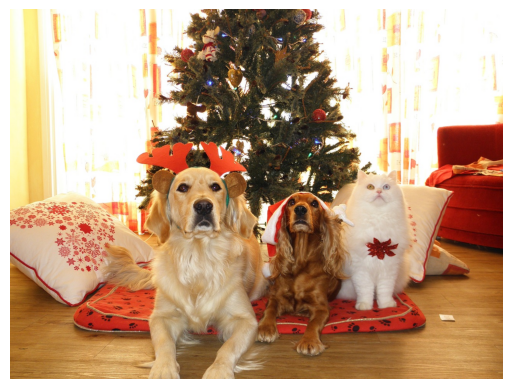

### モデルの読み込み〜実行


0: 480x640 3 dogs, 1 couch, 1 potted plant, 1 bed, 1579.8ms
Speed: 2.5ms preprocess, 1579.8ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)


##### モデルの出力内容

クラス番号: 16, 信頼度: 0.92, 左上座標: (456, 684), 幅: 426px, 高さ: 550px
クラス番号: 16, 信頼度: 0.92, 左上座標: (766, 688), 幅: 250px, 高さ: 427px
クラス番号: 57, 信頼度: 0.90, 左上座標: (1179, 461), 幅: 200px, 高さ: 326px
クラス番号: 16, 信頼度: 0.86, 左上座標: (953, 597), 幅: 184px, 高さ: 375px
クラス番号: 58, 信頼度: 0.31, 左上座標: (636, 276), 幅: 557px, 高さ: 551px
クラス番号: 59, 信頼度: 0.28, 左上座標: (188, 622), 幅: 375px, 高さ: 303px


### モデルの出力内容を元画像に重ねたもの

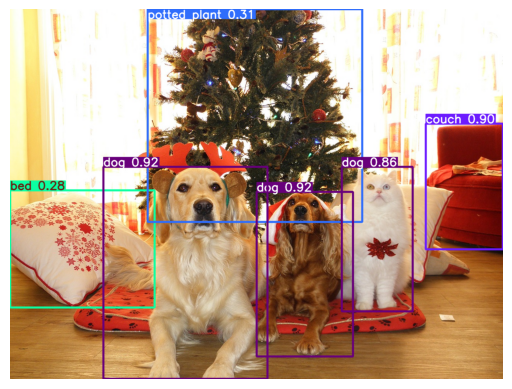

モデルパラメーターのファイルサイズ: 109.33 MB
109.33 MBのモデルで，かなりうまく検出できている


In [ ]:
from IPython.display import Markdown, display
from ultralytics import YOLO
from PIL import Image
import requests
import matplotlib.pyplot as plt
import numpy as np
from io import BytesIO
import os

# 画像の取得と読み込み
url = 'https://cdn.pixabay.com/photo/2015/09/28/15/01/pets-962215_1280.jpg'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")
img_np = np.array(img)

display(Markdown(f"### 元の画像"))
plt.imshow(img_np)
plt.axis('off')
plt.show()

display(Markdown(f"### モデルの読み込み〜実行"))
# YOLOモデルの読み込み
model = YOLO('yolo11x.pt')
# モデルによる推論
results = model(img_np)

# 推論結果の表示
display(Markdown(f"##### モデルの出力内容"))
for result in results:
    for box in result.boxes:
        x, y, w, h = box.xywh[0]
        print(f"クラス番号: {int(box.cls.item())}, 信頼度: {box.conf.item():.2f}, 左上座標: ({x:.0f}, {y:.0f}), 幅: {w:.0f}px, 高さ: {h:.0f}px")

# 検出結果を画像に重ねて表示
display(Markdown(f"### モデルの出力内容を元画像に重ねたもの"))
annotated_img = results[0].plot()
plt.imshow(annotated_img)
plt.axis('off')
plt.show()

# モデルファイルのサイズを表示
model_size = os.path.getsize('yolo11x.pt') / (1024 * 1024)  # MB単位に変換
print(f"モデルパラメーターのファイルサイズ: {model_size:.2f} MB")

print(f"{model_size:.2f} MBのモデルで，かなりうまく検出できている")

### CIFAR-10 データセットを用いた画像分類 (WIP)

Files already downloaded and verified


/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


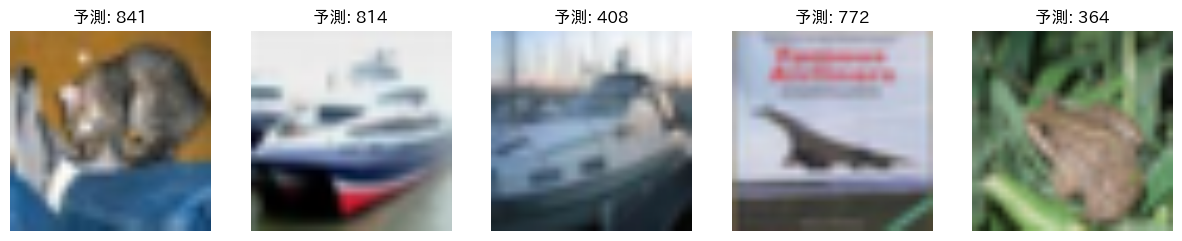

In [18]:
!pip install torch torchvision matplotlib

from torchvision import models, transforms, datasets
import torch
import matplotlib.pyplot as plt

# CIFAR-10データセットと事前学習済みのResNetモデルをロード
transform = transforms.Compose([transforms.Resize(224), transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
dataset = datasets.CIFAR10(root="./data", train=False, transform=transform, download=True)
model = models.resnet18(pretrained=True).eval()

# サンプル画像と予測ラベルを表示
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, (img, _) in enumerate([dataset[i] for i in range(5)]):
    img_t = img.unsqueeze(0)
    with torch.no_grad():
        outputs = model(img_t)
        _, predicted_class = outputs.max(1)
    
    # 画像と予測のプロット
    img_display = img.permute(1, 2, 0) * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
    axes[i].imshow(img_display.numpy().clip(0, 1))
    axes[i].set_title(f"予測: {predicted_class.item()}")
    axes[i].axis("off")
plt.show()

### 航空旅客データセットによる時系列予測 (WIP)

In [ ]:
from fbprophet import Prophet
import pandas as pd

# 航空旅客データセットのロード
data_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(data_url)
data.columns = ["ds", "y"]  # Prophetに合わせた列名に変更

# Prophetモデルの初期化と学習
model = Prophet()
model.fit(data)

# 次の30ヶ月を予測
future = model.make_future_dataframe(periods=30, freq="M")
forecast = model.predict(future)

# 予測結果のプロット
fig = model.plot(forecast)
plt.title("航空旅客の予測")
plt.show()

### クラスタリング (WIP)

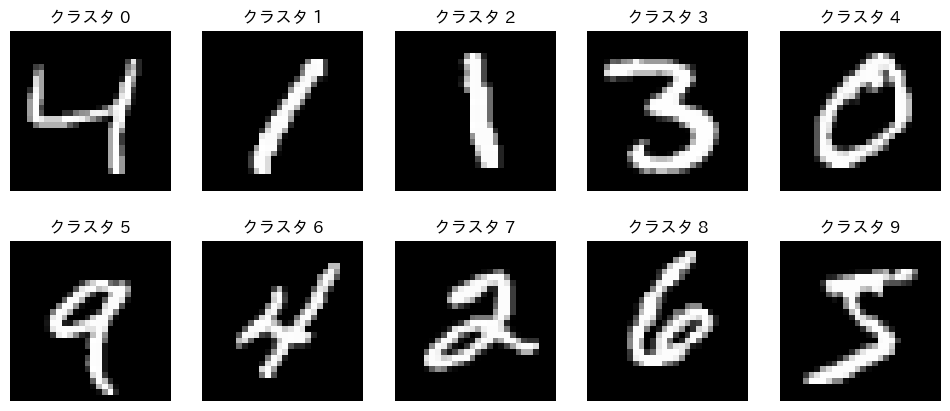

In [51]:
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

# MNIST データセットのロード
mnist = fetch_openml("mnist_784", version=1)
X, y = mnist.data, mnist.target

# K-means クラスタリングの適用
kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(X)

# クラスタに基づくいくつかの数字を表示
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    cluster = (clusters == i)
    img = X[cluster].iloc[0].values.reshape(28, 28)  # 各クラスタから1サンプルを表示
    ax.imshow(img, cmap="gray")
    ax.set_title(f"クラスタ {i}")
    ax.axis("off")
plt.show()

### GPT-2 を使用したテキスト生成 (WIP)

In [ ]:
from transformers import pipeline

# GPT-2 によるテキスト生成パイプラインのロード
generator = pipeline("text-generation", model="gpt2")

# 提示文に基づくテキスト生成
prompt = "未来のある日、"
generated_text = generator(prompt, max_length=50, num_return_sequences=1)[0]["generated_text"]
print(generated_text)

### 多様体学習（非線形次元削減）

In [17]:
%%capture
!pip install umap-learn

In [16]:
from sklearn.datasets import fetch_openml
from umap import UMAP
import matplotlib.pyplot as plt

# Fashion MNIST データセットのロード
fashion_mnist = fetch_openml("Fashion-MNIST", version=1)
X, y = fashion_mnist.data, fashion_mnist.target

# UMAP による次元削減の適用
umap = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_reduced = umap.fit_transform(X)

# UMAP 結果のプロット
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y.astype(int), cmap="Spectral", s=1)
plt.colorbar(scatter)
plt.title("Fashion MNIST の UMAP 表現")
plt.show()

/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


SystemError: CPUDispatcher(<function nn_descent at 0x153881440>) returned a result with an exception set

### 植物画像の分類

In [20]:
# 必要なライブラリのインポート
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from PIL import Image
import requests
from io import BytesIO

# データ変換の定義
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# iNaturalist 2021 mini評価データセットのロード
dataset = datasets.INaturalist(root='./data', version='2021_valid', transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# iNaturalist用に学習された事前学習済みResNet-50モデルの取得
model = models.resnet50(pretrained=False)
checkpoint = torch.hub.load_state_dict_from_url(
    'https://ml-inat-competition-datasets.s3.amazonaws.com/2017/models/resnet50_inat2017.tar.gz',
    map_location='cpu'
)
model.load_state_dict(checkpoint['state_dict'])
model.eval()

# クラスインデックスからクラス名へのマッピングをロード
labels_map_path = os.path.join(dataset.root, '2021_valid', 'labels.json')
with open(labels_map_path) as f:
    class_to_idx = json.load(f)
idx_to_class = {v: k for k, v in class_to_idx.items()}

# 画像と予測結果を表示する関数
def imshow(img, title):
    img = img / 2 + 0.5  # 正規化を元に戻す
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

# バッチから画像を取得し、予測を行う
dataiter = iter(dataloader)
images, labels = dataiter.next()

# モデルで予測
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# 画像と予測結果を表示
for i in range(5):  # 最初の5枚の画像を表示
    imshow(images[i], f'予測: {idx_to_class[predicted[i].item()]}\n実際: {idx_to_class[labels[i].item()]}')

  0%|          | 327680/8931661582 [00:10<78:45:09, 31502.78it/s] 


KeyboardInterrupt: 

### 日本語テキストの感情分析

In [ ]:
%%capture
!pip install protobuf fugashi unidic_lite

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("line-corporation/line-distilbert-base-japanese")
model = AutoModelForSequenceClassification.from_pretrained("line-corporation/line-distilbert-base-japanese")

# Create a sentiment analysis pipeline
classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

# 複数の日本語テキストの感情を予測
texts = [
    "この製品は素晴らしいです！",  # ポジティブ
    "全然気に入りませんでした。",  # ネガティブ
    "普通かなと思いました。",  # ニュートラル
    "とても楽しい経験でした。",  # ポジティブ
    "サービスが遅くて残念です。",  # ネガティブ
    "まあまあでしたが、期待していたほどではなかった。",  # ニュートラル/ネガティブ
    "この店のラーメンは最高だけど、接客が微妙だった。",  # ポジティブ/ネガティブ
    "映画は素晴らしかったが、座席が硬すぎて痛かった。"  # ポジティブ/ネガティブ
]
results = classifier(texts)

# 結果の表示
for text, result in zip(texts, results):
    print(f"テキスト: {text}\nラベル: {result['label']}, 信頼度: {result['score']:.2f}\n")

/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json:   0%|          | 0.00/509 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/275M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at line-corporation/line-distilbert-base-japanese and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


TypeError: DistilBertForSequenceClassification.forward() got an unexpected keyword argument 'token_type_ids'

In [ ]:
%%capture
!pip install fasttext

In [ ]:
import fasttext
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load the general Japanese FastText model
model = fasttext.load_model('cc.ja.300.bin')

# Define simple lexicons of positive and negative words
positive_words = ["良い", "素晴らしい", "楽しい", "最高"]
negative_words = ["悪い", "残念", "嫌い", "悲しい"]

# Get embeddings for positive and negative words
positive_vectors = np.array([model.get_word_vector(word) for word in positive_words])
negative_vectors = np.array([model.get_word_vector(word) for word in negative_words])

# Text samples to analyze
texts = [
    "この製品は素晴らしいです！",  # ポジティブ
    "全然気に入りませんでした。",  # ネガティブ
    "普通かなと思いました。",  # ニュートラル
    "とても楽しい経験でした。",  # ポジティブ
    "サービスが遅くて残念です。",  # ネガティブ
    "まあまあでしたが、期待していたほどではなかった。",  # ニュートラル/ネガティブ
    "この店のラーメンは最高だけど、接客が微妙だった。",  # ポジティブ/ネガティブ
    "映画は素晴らしかったが、座席が硬すぎて痛かった。",  # ポジティブ/ネガティブ
]

# Function to calculate sentiment score
def get_sentiment_score(text):
    words = text.split()
    text_vector = np.mean([model.get_word_vector(word) for word in words if word in model], axis=0)
    pos_similarity = cosine_similarity([text_vector], positive_vectors).mean()
    neg_similarity = cosine_similarity([text_vector], negative_vectors).mean()
    return "ポジティブ" if pos_similarity > neg_similarity else "ネガティブ", max(pos_similarity, neg_similarity)

# Analyze each text
for text in texts:
    label, confidence = get_sentiment_score(text)
    print(f"テキスト: {text}\nラベル: {label}, 信頼度: {confidence:.2f}\n")

ValueError: cc.ja.300.bin cannot be opened for loading!

In [ ]:
from transformers import pipeline

# 日本語の感情分析パイプラインをロード
classifier = pipeline(
    task="sentiment-analysis",
    model="lxyuan/distilbert-base-multilingual-cased-sentiments-student",
    return_all_scores=True
)
# classifier = pipeline("sentiment-analysis", model="lxyuan/distilbert-base-multilingual-cased-sentiments-student")

# 複数の日本語テキストの感情を予測
texts = [
    "この製品は素晴らしいです！",  # ポジティブ
    "全然気に入りませんでした。",  # ネガティブ
    "普通かなと思いました。",  # ニュートラル
    "とても楽しい経験でした。",  # ポジティブ
    "サービスが遅くて残念です。",  # ネガティブ
    "まあまあでしたが、期待していたほどではなかった。",  # ニュートラル/ネガティブ
    "この店のラーメンは最高だけど、接客が微妙だった。",  # ポジティブ/ネガティブ
    "映画は素晴らしかったが、座席が硬すぎて痛かった。"  # ポジティブ/ネガティブ
]
results = classifier(texts)

# 結果の表示
for text, result in zip(texts, results):
    print(f"テキスト: {text}\nラベル: {result['label']}, 信頼度: {result['score']:.2f}\n")

model.safetensors:   2%|1         | 10.5M/541M [00:00<?, ?B/s]

KeyboardInterrupt: 

### 姿勢推定

### 元の画像

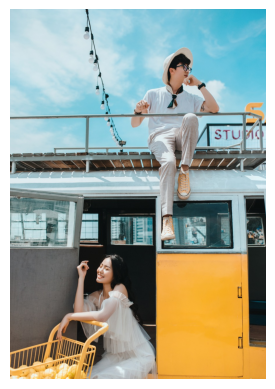

### モデルの読み込み〜実行


0: 640x448 2 persons, 1532.8ms
Speed: 2.1ms preprocess, 1532.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 448)


##### モデルの出力内容

クラス番号: 0, 信頼度: 0.94, 左上座標: (570, 470), 幅: 308px, 高さ: 660px
クラス番号: 0, 信頼度: 0.91, 左上座標: (336, 1064), 幅: 345px, 高さ: 433px


### ポーズ推定結果（元画像なし）

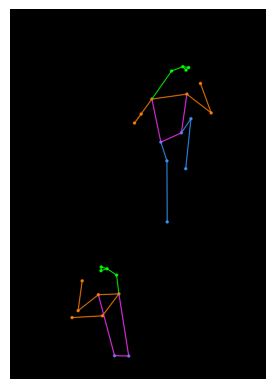

### ポーズ推定結果（画像に重ねてプロット）

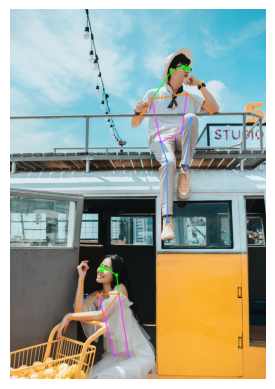

In [98]:
from IPython.display import Markdown, display
from ultralytics import YOLO
from PIL import Image
import requests
import matplotlib.pyplot as plt
import numpy as np
from io import BytesIO

# 画像の取得と読み込み
url = "https://cdn.pixabay.com/photo/2019/06/22/18/30/woman-4292200_1280.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")
img_np = np.array(img)

display(Markdown(f"### 元の画像"))
plt.imshow(img_np)
plt.axis('off')
plt.show()

display(Markdown(f"### モデルの読み込み〜実行"))
# YOLO11ポーズモデルの読み込み
model = YOLO('yolo11x-pose.pt')
# モデルによる推論
results = model(img_np)

# 推論結果の表示
display(Markdown(f"##### モデルの出力内容"))
for result in results:
    for box in result.boxes:
        x, y, w, h = box.xywh[0]
        print(f"クラス番号: {int(box.cls.item())}, 信頼度: {box.conf.item():.2f}, 左上座標: ({x:.0f}, {y:.0f}), 幅: {w:.0f}px, 高さ: {h:.0f}px")

# ポーズのみを新しいキャンバスに描画
display(Markdown(f"### ポーズ推定結果（元画像なし）"))
pose_img = results[0].plot(boxes=False, masks=False, img=np.zeros_like(img_np))
plt.imshow(pose_img)
plt.axis('off')
plt.show()

# ポーズのみを新しいキャンバスに描画
display(Markdown(f"### ポーズ推定結果（画像に重ねてプロット）"))
pose_img = results[0].plot(boxes=False)
plt.imshow(pose_img)
plt.axis('off')
plt.show()

In [100]:
keypoint_names = ["鼻", "左目", "右目", "左耳", "右耳", "左肩", "右肩", "左肘", "右肘", "左手首", "右手首", "左腰", "右腰", "左膝", "右膝", "左足首", "右足首"]
pd.DataFrame([
    {'person': person, 'name': keypoint_names[keypoint_id], 'x': xy[0], 'y': xy[1]}
    for person, result in enumerate(results)
    for keypoint in result.keypoints
    for keypoint_id, xy in enumerate(keypoint.xy[0].numpy())
])

,person,name,x,y
0,0,鼻,608.968018,211.149628
1,0,左目,617.014160,202.383545
2,0,右目,597.218689,199.049622
3,0,左耳,0.000000,0.000000
4,0,右耳,558.177734,214.029419
5,0,左肩,611.060974,294.791656
6,0,右肩,490.368286,311.518799
7,0,左肘,695.929810,359.464111
8,0,右肘,430.587585,394.231079
9,0,左手首,658.131042,257.699097


### 元の画像

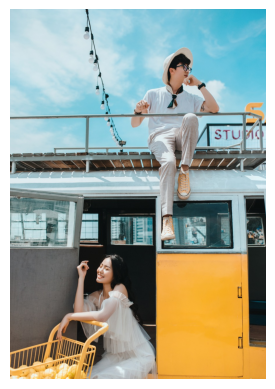

### モデルの読み込み〜実行

100%|██████████| 113M/113M [01:01<00:00, 1.93MB/s] 



0: 640x448 2 persons, 1803.7ms
Speed: 3.1ms preprocess, 1803.7ms inference, 8.6ms postprocess per image at shape (1, 3, 640, 448)


##### モデルの出力内容

クラス番号: 0, 信頼度: 0.94, 左上座標: (570, 470), 幅: 308px, 高さ: 660px
クラス番号: 0, 信頼度: 0.91, 左上座標: (336, 1064), 幅: 345px, 高さ: 433px


### モデルの出力内容を元画像に重ねたもの

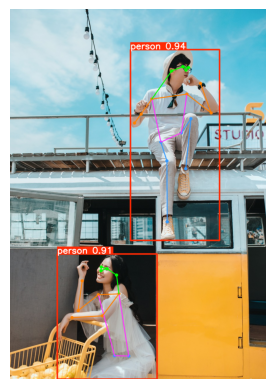

モデルパラメーターのファイルサイズ: 109.33 MB
109.33 MBのモデルで，かなりうまく検出できている


In [65]:
from IPython.display import Markdown, display
from ultralytics import YOLO
from PIL import Image
import requests
import matplotlib.pyplot as plt
import numpy as np
from io import BytesIO
import os

# 画像の取得と読み込み
url = "https://cdn.pixabay.com/photo/2019/06/22/18/30/woman-4292200_1280.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")
img_np = np.array(img)

display(Markdown(f"### 元の画像"))
plt.imshow(img_np)
plt.axis('off')
plt.show()

display(Markdown(f"### モデルの読み込み〜実行"))
# YOLOモデルの読み込み
model = YOLO('yolo11x-pose.pt')
# モデルによる推論
results = model(img_np)

# 推論結果の表示
display(Markdown(f"##### モデルの出力内容"))
for result in results:
    for box in result.boxes:
        x, y, w, h = box.xywh[0]
        print(f"クラス番号: {int(box.cls.item())}, 信頼度: {box.conf.item():.2f}, 左上座標: ({x:.0f}, {y:.0f}), 幅: {w:.0f}px, 高さ: {h:.0f}px")

# 検出結果を画像に重ねて表示
display(Markdown(f"### モデルの出力内容を元画像に重ねたもの"))
annotated_img = results[0].plot()
plt.imshow(annotated_img)
plt.axis('off')
plt.show()

# モデルファイルのサイズを表示
model_size = os.path.getsize('yolo11x.pt') / (1024 * 1024)  # MB単位に変換
print(f"モデルパラメーターのファイルサイズ: {model_size:.2f} MB")

print(f"{model_size:.2f} MBのモデルで，かなりうまく検出できている")

In [54]:
%%capture
!pip install torch torchvision opencv-python

In [61]:
import torch
import torchvision.transforms as transforms
import cv2
import numpy as np
from PIL import Image
from urllib.request import urlopen

# Load the image from a public-domain source
image_url = "https://cdn.pixabay.com/photo/2019/06/22/18/30/woman-4292200_1280.jpg"

with urlopen(image_url) as response:
    image = Image.open(response).convert('RGB')

# Define the transformation
transform = transforms.Compose([
    transforms.Resize((256, 192)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Apply the transformation
input_tensor = transform(image).unsqueeze(0)

# Load the LitePose model
model = torch.hub.load('mit-han-lab/litepose', 'litepose_auto_s', pretrained=True)
model.eval()

# Perform pose estimation
with torch.no_grad():
    output = model(input_tensor)

# Process the output
heatmaps = output[0].cpu().numpy()
keypoints = []
for i in range(heatmaps.shape[0]):
    heatmap = heatmaps[i]
    _, conf, _, point = cv2.minMaxLoc(heatmap)
    x, y = point
    keypoints.append((x, y, conf))

# Draw keypoints on the image
annotated_image = np.array(image)
for x, y, conf in keypoints:
    if conf > 0.5:  # Confidence threshold
        cv2.circle(annotated_image, (x, y), 5, (0, 255, 0), -1)

# Save the annotated image
output_path = f"{OUTPUT_DIR}/litepose_estimation_result.jpg"
cv2.imwrite(output_path, cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))

# Display the result
from IPython.display import Image as IPImage
IPImage(output_path)

HTTPError: HTTP Error 403: Forbidden